              precision    recall  f1-score   support

 non-healing       0.50      0.33      0.40         3
     healing       0.86      0.92      0.89        13

   micro avg       0.81      0.81      0.81        16
   macro avg       0.68      0.63      0.64        16
weighted avg       0.79      0.81      0.80        16
 samples avg       0.81      0.81      0.81        16

Accuracy: 81.25 %


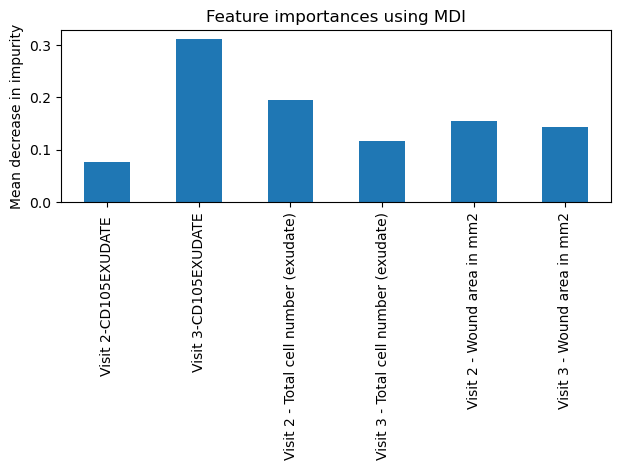

[[-0.03832842  0.75985414]
 [-0.41975585  1.0034325 ]
 [ 0.7116757   0.3223936 ]
 [-0.02684191  0.7261108 ]
 [-0.32104075  0.79732955]
 [-0.03029588  0.57663596]
 [-0.05007358  0.87839305]
 [-0.32728094  1.0606942 ]
 [-0.04115859  0.9921553 ]
 [ 0.70333225  0.38744745]
 [ 0.00494161  0.8009851 ]
 [ 0.3762265   0.60029674]
 [-0.3267393   1.1232216 ]
 [ 0.44524446  0.596774  ]
 [-0.33056694  1.1131655 ]
 [-0.3392102   1.1369711 ]]
[[False  True]
 [False  True]
 [ True False]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [ True False]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]]


<Figure size 40000x12000 with 0 Axes>

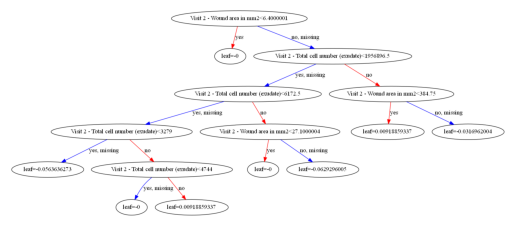

--------------------------------------------------------------------------------------------------


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model


Treatment=pd.read_csv("../dissertation/CD105 full.csv")
Treatment_test=pd.read_csv("../dissertation/CD105 full test.csv")
X_train=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
df_y_test=Treatment_test.iloc[:,0]


y_train = to_categorical(df_y)
y_test = to_categorical(df_y_test)


names=["CD V2","CD V3","V1","V2","V3"]
W_tree=2


clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="exact",
                 objective="reg:pseudohubererror",
                  eta=0.09,
                 # max_depth=4,
                 # subsample=0.9,
                  colsample_bytree=0.7,
                  colsample_bylevel=0.9,
                # colsample_bynode=0.6,
                  reg_lambda=0.8,
                  reg_alpha=0.4,
                  rate_drop=1,
                  skip_drop=0.4,
                  one_drop=1,
                 # sample_type="weighted",
                  
    )





clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["non-healing","healing"]


#Which_data=df_y_test
Which_data=df_y

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)